In [1]:
"""
Exploratory Data Analysis (EDA)

This section performs initial exploration of the wildfire structural damage dataset.
It includes:

- Overview of dataset structure: number of rows, columns, and data types.
- Summary statistics for numerical and categorical features.
- Analysis of missing values and strategy suggestions for imputation.
- Outlier detection and data consistency checks.
- Feature selection and engineering opportunities.
- Early pattern identification relevant to the damage prediction problem.

The goal of this EDA is to understand data quality, structure, and key relationships
before proceeding to modeling.
"""


'\nExploratory Data Analysis (EDA)\n\nThis section performs initial exploration of the wildfire structural damage dataset.\nIt includes:\n\n- Overview of dataset structure: number of rows, columns, and data types.\n- Summary statistics for numerical and categorical features.\n- Analysis of missing values and strategy suggestions for imputation.\n- Outlier detection and data consistency checks.\n- Feature selection and engineering opportunities.\n- Early pattern identification relevant to the damage prediction problem.\n\nThe goal of this EDA is to understand data quality, structure, and key relationships\nbefore proceeding to modeling.\n'

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Wildfire_Capstone.csv')
df.head()

C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_12968\1433512987.py:1: DtypeWarning: Columns (13,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('C:/Users/Mriganko Saha/Downloads/b8aeb030-140d-43d2-aa29-1a80862e3d62.csv')


,_id,OBJECTID,* Damage,* Street Number,* Street Name,"* Street Type (e.g. road, drive, lane, etc.)","Street Suffix (e.g. apt. 23, blding C)",* City,State,Zip Code,...,Fire Name (Secondary),APN (parcel),Assessed Improved Value (parcel),Year Built (parcel),Site Address (parcel),GLOBALID,Latitude,Longitude,x,y
0,1,1,No Damage,8376.0,Quail Canyon,Road,NaN,Winters,CA,NaN,...,Quail,0101090290,510000.0,1997.0,8376 QUAIL CANYON RD VACAVILLE CA 95688,e1919a06-b4c6-476d-99e5-f0b45b070de8,38.474960,-122.044465,-1.358593e+07,4.646741e+06
1,2,2,Affected (1-9%),8402.0,Quail Canyon,Road,NaN,Winters,CA,NaN,...,Quail,0101090270,573052.0,1980.0,8402 QUAIL CANYON RD VACAVILLE CA 95688,b090eeb6-5b18-421e-9723-af7c9144587c,38.477442,-122.043252,-1.358579e+07,4.647094e+06
2,3,3,No Damage,8430.0,Quail Canyon,Road,NaN,Winters,CA,NaN,...,Quail,0101090310,350151.0,2004.0,8430 QUAIL CANYON RD VACAVILLE CA 95688,268da70b-753f-46aa-8fb1-327099337395,38.479358,-122.044585,-1.358594e+07,4.647366e+06
3,4,4,No Damage,3838.0,Putah Creek,Road,NaN,Winters,CA,NaN,...,Quail,0103010240,134880.0,1981.0,3838 PUTAH CREEK RD WINTERS CA 95694,64d4a278-5ee9-414a-8bf4-247c5b5c60f9,38.487313,-122.015115,-1.358266e+07,4.648497e+06
4,5,5,No Damage,3830.0,Putah Creek,Road,NaN,Winters,CA,NaN,...,Quail,0103010220,346648.0,1980.0,3830 PUTAH CREEK RD WINTERS CA 95694,1b44b214-01fd-4f06-b764-eb42a1ec93d7,38.485636,-122.016122,-1.358277e+07,4.648259e+06


In [5]:
df.count()

_id                                                             100230
OBJECTID                                                        100230
* Damage                                                        100230
* Street Number                                                  95810
* Street Name                                                    94744
* Street Type (e.g. road, drive, lane, etc.)                     87033
Street Suffix (e.g. apt. 23, blding C)                           44148
* City                                                           68616
State                                                           100223
Zip Code                                                         47429
* CAL FIRE Unit                                                 100230
County                                                          100200
Community                                                        52892
Battalion                                                         6398
* Inci

In [7]:
len(df)

100230

In [9]:
missing_values = df.isnull().sum()

In [11]:
threshold = 0.5  # 50% missing data threshold
columns_to_drop = missing_values[missing_values / len(df) > threshold].index

df_cleaned = df.drop(columns=columns_to_drop)

In [13]:
df_cleaned = df_cleaned.ffill()

In [15]:
print(df_cleaned.isnull().sum())

_id                                              0
OBJECTID                                         0
* Damage                                         0
* Street Number                                  0
* Street Name                                    0
* Street Type (e.g. road, drive, lane, etc.)     0
* City                                           0
State                                            0
* CAL FIRE Unit                                  0
County                                           0
Community                                       60
* Incident Name                                  0
Incident Number (e.g. CAAEU 123456)              0
Incident Start Date                              0
Hazard Type                                      0
* Structure Type                                 0
Structure Category                               0
* Roof Construction                              0
* Eaves                                          0
* Vent Screen                  

In [17]:
df_cleaned.describe(include="all")

,_id,OBJECTID,* Damage,* Street Number,* Street Name,"* Street Type (e.g. road, drive, lane, etc.)",* City,State,* CAL FIRE Unit,County,...,* Fence Attached to Structure,APN (parcel),Assessed Improved Value (parcel),Year Built (parcel),Site Address (parcel),GLOBALID,Latitude,Longitude,x,y
count,100230.000000,100230.000000,100230,1.002300e+05,100230,100230,100230,100230,100230,100230,...,100230,100230,1.002300e+05,100230.000000,100230,100230,100230.000000,100230.000000,1.002300e+05,1.002300e+05
unique,NaN,NaN,6,NaN,9820,27,442,1,27,50,...,4,56857,NaN,NaN,53338,100230,NaN,NaN,NaN,NaN
top,NaN,NaN,Destroyed (>50%),NaN,Creston,Road,Unincorporated,CA,BTU,Butte,...,No Fence,018060086000,NaN,NaN,,e1919a06-b4c6-476d-99e5-f0b45b070de8,NaN,NaN,NaN,NaN
freq,NaN,NaN,53879,NaN,4119,50226,17870,100230,28774,28715,...,67792,259,NaN,NaN,1850,1,NaN,NaN,NaN,NaN
mean,50115.500000,50227.779717,NaN,3.733165e+04,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.660990e+05,1679.531757,NaN,NaN,38.322953,-121.179297,-1.348962e+07,4.629002e+06
std,28934.053078,29107.678335,NaN,5.154151e+06,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,9.443224e+06,706.031747,NaN,NaN,2.019086,1.538342,1.712474e+05,2.825063e+05
min,1.000000,1.000000,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000e+00,0.000000,NaN,NaN,32.592548,-123.774580,-1.377852e+07,3.841346e+06
25%,25058.250000,25058.250000,NaN,8.260000e+02,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.728900e+04,1946.000000,NaN,NaN,37.350926,-122.316162,-1.361617e+07,4.488135e+06
50%,50115.500000,50115.500000,NaN,3.921500e+03,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.446830e+05,1975.000000,NaN,NaN,38.692955,-121.600277,-1.353648e+07,4.677785e+06
75%,75172.750000,75172.750000,NaN,9.435000e+03,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.100000e+05,1994.000000,NaN,NaN,39.763874,-120.509278,-1.341503e+07,4.831688e+06


In [25]:
# 1. Record the number of rows, columns, and data types
print("Shape:", df_cleaned.shape)
print("\nData types:\n", df_cleaned.dtypes)

Shape: (100230, 35)

Data types:
 _id                                               int64
OBJECTID                                          int64
* Damage                                         object
* Street Number                                 float64
* Street Name                                    object
* Street Type (e.g. road, drive, lane, etc.)     object
* City                                           object
State                                            object
* CAL FIRE Unit                                  object
County                                           object
Community                                        object
* Incident Name                                  object
Incident Number (e.g. CAAEU 123456)              object
Incident Start Date                              object
Hazard Type                                      object
* Structure Type                                 object
Structure Category                               object
* Roof Constru

In [27]:
# 2. Basic statistics for numerical features
print("\nNumerical statistics:\n", df_cleaned.describe(include=[np.number]))


Numerical statistics:
                  _id       OBJECTID  * Street Number  \
count  100230.000000  100230.000000     1.002300e+05   
mean    50115.500000   50227.779717     3.733165e+04   
std     28934.053078   29107.678335     5.154151e+06   
min         1.000000       1.000000     0.000000e+00   
25%     25058.250000   25058.250000     8.260000e+02   
50%     50115.500000   50115.500000     3.921500e+03   
75%     75172.750000   75172.750000     9.435000e+03   
max    100230.000000  101221.000000     1.410065e+09   

       Assessed Improved Value (parcel)  Year Built (parcel)       Latitude  \
count                      1.002300e+05        100230.000000  100230.000000   
mean                       7.660990e+05          1679.531757      38.322953   
std                        9.443224e+06           706.031747       2.019086   
min                        0.000000e+00             0.000000      32.592548   
25%                        5.728900e+04          1946.000000      37.350926 

In [29]:
# 3. Unique values and frequencies for categorical features
categorical_cols = df_cleaned.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col} - Unique values and counts:\n", df_cleaned[col].value_counts(dropna=False))


* Damage - Unique values and counts:
 * Damage
Destroyed (>50%)    53879
No Damage           40895
Affected (1-9%)      3438
Minor (10-25%)       1018
Major (26-50%)        564
Inaccessible          436
Name: count, dtype: int64

* Street Name - Unique values and counts:
 * Street Name
Creston             4119
Pentz                751
Skyway               546
Clark                461
Empire Grade         382
                    ... 
St, Helena Creek       1
Knowls                 1
Seigler Springs        1
J.D.Kingcade           1
Mule Town              1
Name: count, Length: 9820, dtype: int64

* Street Type (e.g. road, drive, lane, etc.) - Unique values and counts:
 * Street Type (e.g. road, drive, lane, etc.)
Road         50226
Drive        15491
Lane         10386
Way           5179
Court         3858
Street        3629
Other         2450
Avenue        2249
Trail         1609
Circle        1543
Place         1155
Hwy            599
Route          428
Boulevard      386
Parkway    

In [33]:
# 4. Missing values and strategies
# Done before

In [35]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_cleaned[(df_cleaned[col] < (Q1 - 1.5 * IQR)) | (df_cleaned[col] > (Q3 + 1.5 * IQR))]
    print(f"\n{col} - Number of potential outliers: {len(outliers)}")


_id - Number of potential outliers: 0

OBJECTID - Number of potential outliers: 0

* Street Number - Number of potential outliers: 9625

Assessed Improved Value (parcel) - Number of potential outliers: 9883

Year Built (parcel) - Number of potential outliers: 15130

Latitude - Number of potential outliers: 3470

Longitude - Number of potential outliers: 6067

x - Number of potential outliers: 6067

y - Number of potential outliers: 1297


In [37]:
# 6. Standardize string columns
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.lower()

In [61]:
# 7. Feature selection and engineering
#Also handling the missing values in the distance column

# Clean the column: extract numeric values and convert to float
col_name = 'Distance - Residence to Utility/Misc Structure &gt; 120 SQFT'

# Extract numeric values (including decimals), convert to float, and handle errors
df['Distance_Clean'] = df[col_name].astype(str).str.extract(r'(\d+\.?\d*)')
df['Distance_Clean'] = pd.to_numeric(df['Distance_Clean'], errors='coerce')

# Fill missing values with the median
median_value = df['Distance_Clean'].median()
df['Distance_Clean'].fillna(median_value)

# Show summary statistics of the cleaned column
df['Distance_Clean'].describe()


count    14345.000000
mean        35.553154
std          8.957185
min         30.000000
25%         30.000000
50%         30.000000
75%         50.000000
max         50.000000
Name: Distance_Clean, dtype: float64

In [63]:
selected = [
    '* Damage', 'Latitude', 'Longitude', 'Assessed Improved Value (parcel)',
    'Year Built (parcel)', 'Distance_Clean', '* Incident Name',
     'County', '* City', 'State'
]
df_selected = df[selected].copy()
df_selected['ageofstructure'] = 2025 - df_selected['Year Built (parcel)']
median_value = df_selected['Assessed Improved Value (parcel)'].median()
df_selected['is_high_value'] = df_selected['Assessed Improved Value (parcel)'] > median_value
df_selected['distance_band'] = pd.cut(
    df_selected['Distance_Clean'],
    bins=[-np.inf, 10, 50, np.inf],
    labels=['Near', 'Medium', 'Far']
)

In [67]:
df_selected['distance_band'].describe()

count      14345
unique         1
top       Medium
freq       14345
Name: distance_band, dtype: object

In [71]:
print("\nDamage distribution by structure age:")
print(df_selected.groupby(pd.cut(df_selected['ageofstructure'], bins=[0, 20, 50, 100, np.inf]))['* Damage'].value_counts())


Damage distribution by structure age:
ageofstructure  * Damage        
(0.0, 20.0]     No Damage            2796
                Destroyed (>50%)     1328
                Affected (1-9%)       280
                Minor (10-25%)         50
                Inaccessible           22
                Major (26-50%)         17
(20.0, 50.0]    Destroyed (>50%)    14301
                No Damage           11324
                Affected (1-9%)      1215
                Minor (10-25%)        298
                Major (26-50%)        153
                Inaccessible           61
(50.0, 100.0]   Destroyed (>50%)    15054
                No Damage            7854
                Affected (1-9%)       754
                Minor (10-25%)        206
                Major (26-50%)        122
                Inaccessible           72
(100.0, inf]    Destroyed (>50%)     6743
                No Damage            6455
                Affected (1-9%)       405
                Minor (10-25%)        155
    

C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_12968\3893359860.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_selected.groupby(pd.cut(df_selected['ageofstructure'], bins=[0, 20, 50, 100, np.inf]))['* Damage'].value_counts())


In [73]:
print("\nDamage distribution by property value tier:")
print(df_selected.groupby('is_high_value')['* Damage'].value_counts())


Damage distribution by property value tier:
is_high_value  * Damage        
False          Destroyed (>50%)    31366
               No Damage           19395
               Affected (1-9%)      1333
               Minor (10-25%)        456
               Inaccessible          314
               Major (26-50%)        277
True           Destroyed (>50%)    22513
               No Damage           21500
               Affected (1-9%)      2105
               Minor (10-25%)        562
               Major (26-50%)        287
               Inaccessible          122
Name: count, dtype: int64


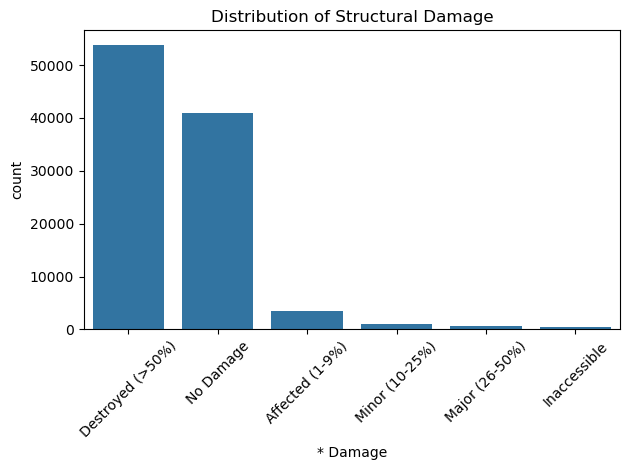

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_selected, x='* Damage', order=df_selected['* Damage'].value_counts().index)
plt.title('Distribution of Structural Damage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


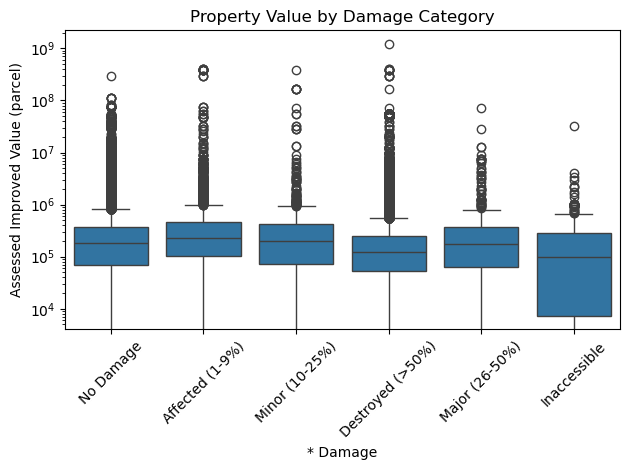

In [83]:
sns.boxplot(data=df_selected, x='* Damage', y='Assessed Improved Value (parcel)')
plt.yscale('log')  # Optional: if values are skewed
plt.title('Property Value by Damage Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


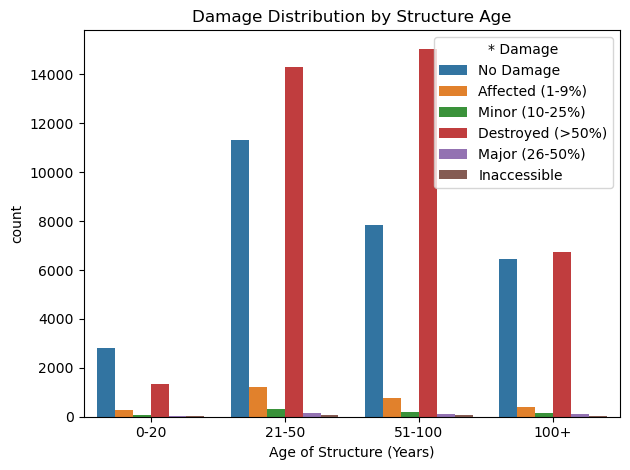

In [85]:
df_selected['age_bin'] = pd.cut(df_selected['ageofstructure'], bins=[0, 20, 50, 100, np.inf], labels=['0-20', '21-50', '51-100', '100+'])

sns.countplot(data=df_selected, x='age_bin', hue='* Damage')
plt.title('Damage Distribution by Structure Age')
plt.xlabel('Age of Structure (Years)')
plt.tight_layout()
plt.show()


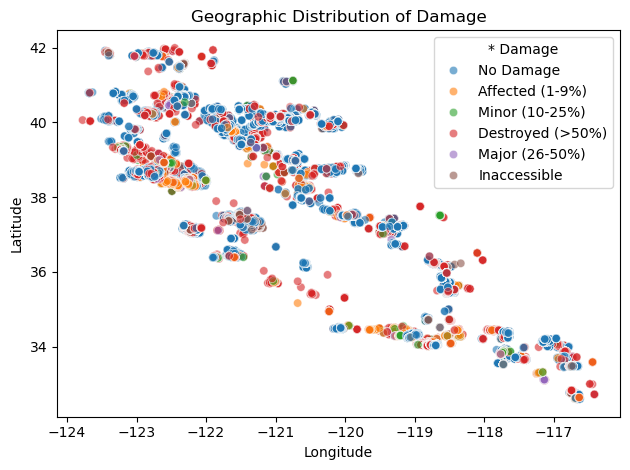

In [87]:
sns.scatterplot(data=df_selected, x='Longitude', y='Latitude', hue='* Damage', alpha=0.6)
plt.title('Geographic Distribution of Damage')
plt.tight_layout()
plt.show()


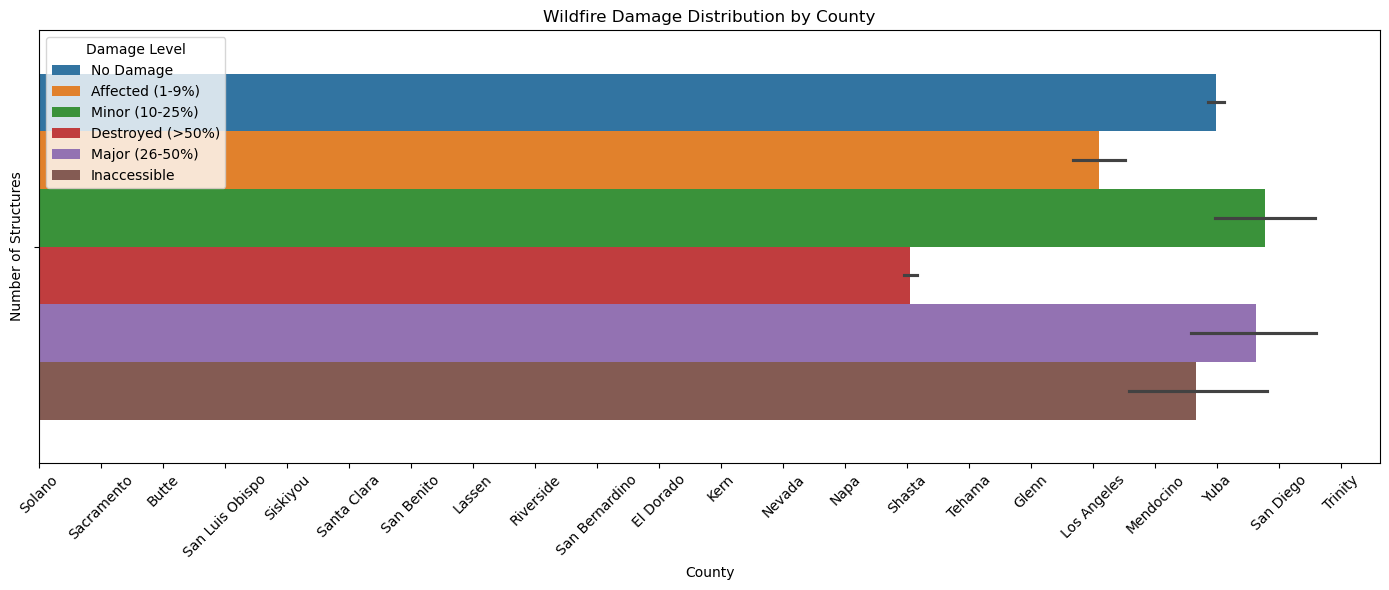

In [107]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_selected, x='County', hue='* Damage')
plt.title('Wildfire Damage Distribution by County')
plt.xlabel('County')
plt.ylabel('Number of Structures')
plt.xticks(rotation=45)
plt.legend(title='Damage Level')
plt.tight_layout()
plt.show()

In [113]:
matrix=df_selected.select_dtypes(include='number').corr()

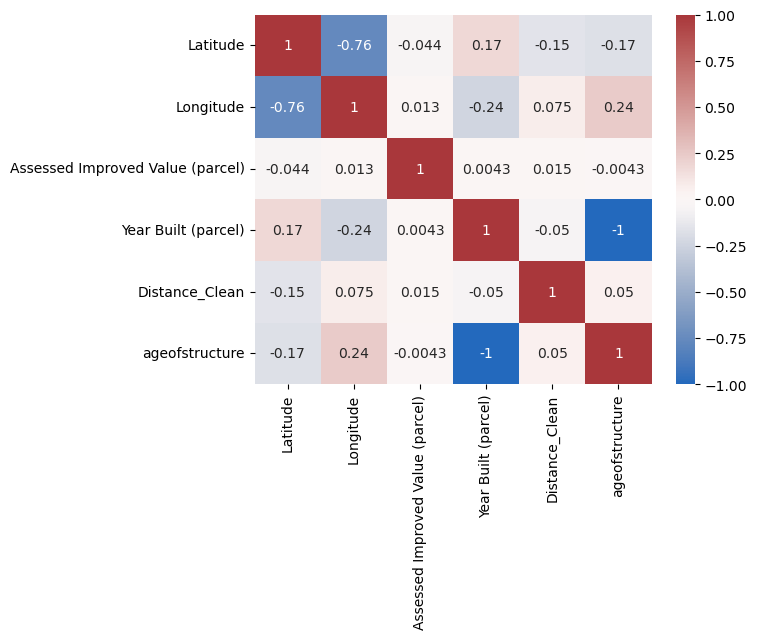

In [115]:
sns.heatmap(matrix, annot=True, vmax=1, vmin=-1, center=0, cmap='vlag')
plt.show()

In [123]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

# 1. Assume df_cleaned is your preprocessed DataFrame
# Select features and target
features = [
    'Latitude', 'Longitude', 'Assessed Improved Value (parcel)',
    'Year Built (parcel)', 'Distance_Clean', 'ageofstructure'
]
X = df_selected[features]
y = df_selected['* Damage']

# 2. Encode the target if it's in string format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

from sklearn.impute import SimpleImputer

# Impute numerical columns with median
imputer = SimpleImputer(strategy='median')
X_1 = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_1, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 5. Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_resampled), y=y_train_resampled)
class_weight_dict = dict(enumerate(class_weights))

# 6. Train model with class weights
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)
model.fit(X_train_resampled, y_train_resampled)

# 7. Evaluate
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Confusion Matrix:
[[ 104  359    3   15   27  179]
 [ 361 9427   39   95  125  729]
 [   3    6   51    3    1   23]
 [  14   69    2    6    5   17]
 [  19  113    2    9   17   44]
 [ 183  742   48   71   76 7059]]

Classification Report:
                  precision    recall  f1-score   support

 Affected (1-9%)       0.15      0.15      0.15       687
Destroyed (>50%)       0.88      0.87      0.88     10776
    Inaccessible       0.35      0.59      0.44        87
  Major (26-50%)       0.03      0.05      0.04       113
  Minor (10-25%)       0.07      0.08      0.07       204
       No Damage       0.88      0.86      0.87      8179

        accuracy                           0.83     20046
       macro avg       0.39      0.44      0.41     20046
    weighted avg       0.84      0.83      0.83     20046



C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_12968\624048285.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts.values, palette='Set2')


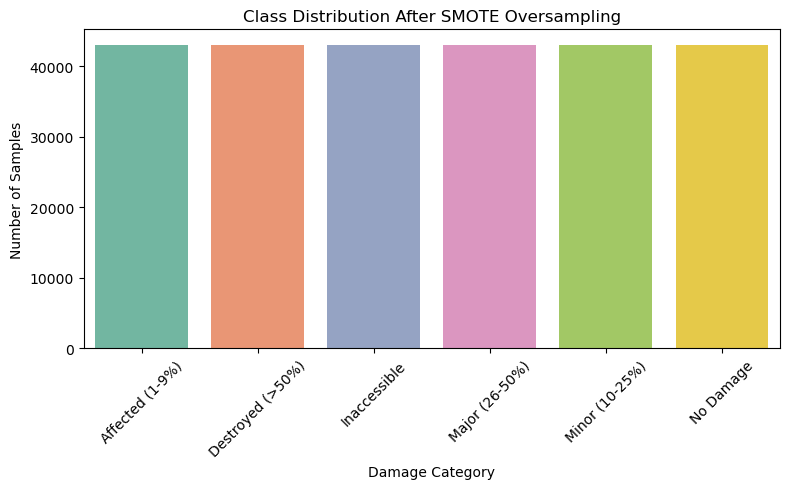

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# If you used LabelEncoder earlier
class_names = label_encoder.inverse_transform(sorted(np.unique(y_train_resampled)))

# Create a pandas Series for counts
class_counts = pd.Series(y_train_resampled).value_counts().sort_index()

# Plot using seaborn
plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=class_counts.values, palette='Set2')

plt.title('Class Distribution After SMOTE Oversampling')
plt.xlabel('Damage Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
